# Bias-Analyse der News-Annotationen

Dieses Notebook untersucht mögliche Bias-Signale in den produktiven LLM-Annotationen auf zwei Ebenen: zunächst Häufigkeiten und Bewertungsrichtungen der vier Indikatoren insgesamt, anschließend Unterschiede zwischen Vereinen. Beobachtete Unterschiede können auch durch die Nachrichteninhalte oder reale sportliche Verhältnisse entstehen und belegen allein keinen Bias des LLMs.

Das Notebook liest bestehende Pipeline-Artefakte ein, ruft Ollama nicht auf und verändert keine Pipeline-Artefakte. Artikeltexte, Titel und Evidenzpassagen werden nicht ausgegeben.

In [42]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter
from matplotlib_inline.backend_inline import set_matplotlib_formats

from buli_news.news.annotations.results import read_existing_annotations

SEASON = 2025
TASKS_PATH = Path(f"../data/interim/{SEASON}/news/annotations/tasks.jsonl")
RESULTS_PATH = Path(f"../data/interim/{SEASON}/news/annotations/results.jsonl")
HUMAN_RUN_PATH = Path(
    f"helpers/human_annotations/human_annotations_{SEASON}_200_seed_20260906.xlsx"
)

INDICATOR_LABELS = {
    "sporting_form": "Sportliche Form",
    "personnel_situation": "Personalsituation",
    "physical_readiness": "Physische Einsatzbereitschaft",
    "confidence_and_motivation": "Selbstvertrauen und Motivation",
}
RATING_VALUES = {
    "strong_negative": -2,
    "negative": -1,
    "neutral": 0,
    "positive": 1,
    "strong_positive": 2,
}
TASK_METADATA_COLUMNS = [
    "task_id",
    "content_id",
    "request_id",
    "match_id",
    "matchday",
    "side",
    "target_team",
    "opponent_team",
    "source_host",
]

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")
plt.style.use("seaborn-v0_8-whitegrid")
# Scharfe Notebook-Ausgaben und hochauflösende manuelle Bildexporte.
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300})
set_matplotlib_formats("retina")

## 1. Daten einlesen

Eingelesen werden die produktiven Annotationen und die dazugehörigen textfreien Task-Metadaten. Die Artikeltexte werden beim Einlesen verworfen und nicht im Notebook angezeigt.

In [43]:
for path in (TASKS_PATH, RESULTS_PATH):
    if not path.is_file():
        raise FileNotFoundError(f"Eingabedatei fehlt: {path}")

task_rows = []
with TASKS_PATH.open("r", encoding="utf-8-sig") as file:
    for line in file:
        if line.strip():
            task = json.loads(line)
            task_rows.append({column: task[column] for column in TASK_METADATA_COLUMNS})

tasks = pd.DataFrame(task_rows)
annotations = read_existing_annotations(RESULTS_PATH)

if tasks["task_id"].duplicated().any():
    raise ValueError("Die Task-Datei enthält doppelte task_id-Werte.")

annotations_by_task_id = {annotation["task_id"]: annotation for annotation in annotations}
if len(annotations_by_task_id) != len(annotations):
    raise ValueError("Die Ergebnisdatei enthält mehrere Annotationen für dieselbe task_id.")

unknown_task_ids = set(annotations_by_task_id) - set(tasks["task_id"])
if unknown_task_ids:
    raise ValueError(f"Für {len(unknown_task_ids)} Annotationen fehlt der zugehörige Task.")

print(f"Tasks: {len(tasks)}")
print(f"Produktive Annotationen: {len(annotations)}")
print(f"Tasks ohne Annotation: {len(tasks) - len(annotations)}")
display(tasks.head())

Tasks: 48466
Produktive Annotationen: 48465
Tasks ohne Annotation: 1


,task_id,content_id,request_id,match_id,matchday,side,target_team,opponent_team,source_host
0,news_annotation_task_sha256:6862e3dc05f1c16ba8...,content_sha256:a1e4631d06cc3aec2a4d6c387ffa60d...,bl1_2025_77256_home_team_context,77256,1,home,FC Bayern München,RB Leipzig,deutschlandfunk.de
1,news_annotation_task_sha256:e544076b484d67ab01...,content_sha256:b194e9e4372394528aff8bddd507c15...,bl1_2025_77256_home_team_context,77256,1,home,FC Bayern München,RB Leipzig,90min.de
2,news_annotation_task_sha256:32d5fab03eca4fa4a9...,content_sha256:6359179a82489cbab4196f9146657d1...,bl1_2025_77256_home_team_context,77256,1,home,FC Bayern München,RB Leipzig,az-online.de
3,news_annotation_task_sha256:a660f527e23be1c411...,content_sha256:5bc2d80b3f79cdb941ddba821eb82cf...,bl1_2025_77256_home_team_context,77256,1,home,FC Bayern München,RB Leipzig,90min.de
4,news_annotation_task_sha256:d74be91338a96149bc...,content_sha256:2e15dc4b2b47df79492eb58a49d341e...,bl1_2025_77256_home_team_context,77256,1,home,FC Bayern München,RB Leipzig,n-tv.de


## 2. Bias auf Indikatorebene

Wie häufig werden die vier Indikatoren erwähnt und wie positiv oder negativ fallen ihre Bewertungen aus? Die Gesamtübersicht dient als Einstieg und als Referenz für spätere Vereinsvergleiche. Mention-Anteile und Ratings innerhalb der erwähnten Fälle werden getrennt betrachtet.

Beispielsweise kann ein überwiegend positives Motivationsrating sowohl die Berichterstattung als auch eine Bewertungstendenz des LLMs widerspiegeln. Die Verteilung allein kann diese Ursachen nicht trennen.

In [44]:
tasks_by_task_id = tasks.set_index("task_id").to_dict(orient="index")

annotation_rows = []
for task_id, annotation in annotations_by_task_id.items():
    task = tasks_by_task_id[task_id]
    for indicator, indicator_label in INDICATOR_LABELS.items():
        rating_label = annotation[indicator]["rating"]
        mentioned = rating_label != "not_mentioned"
        annotation_rows.append({
            "task_id": task_id,
            "target_team": task["target_team"],
            "indicator": indicator_label,
            "mentioned": int(mentioned),
            "rating": RATING_VALUES[rating_label] if mentioned else None,
        })

annotation_data = pd.DataFrame(annotation_rows)

### Relative Häufigkeit der Erwähnungen

Jeder Balken zeigt den Anteil produktiver Tasks, in denen der jeweilige Indikator ein Rating ungleich `not_mentioned` erhalten hat. Die Beschriftung nennt zusätzlich die absolute Anzahl. Da ein Task mehrere Indikatoren enthalten kann, müssen sich die vier Anteile nicht auf 100 % summieren.

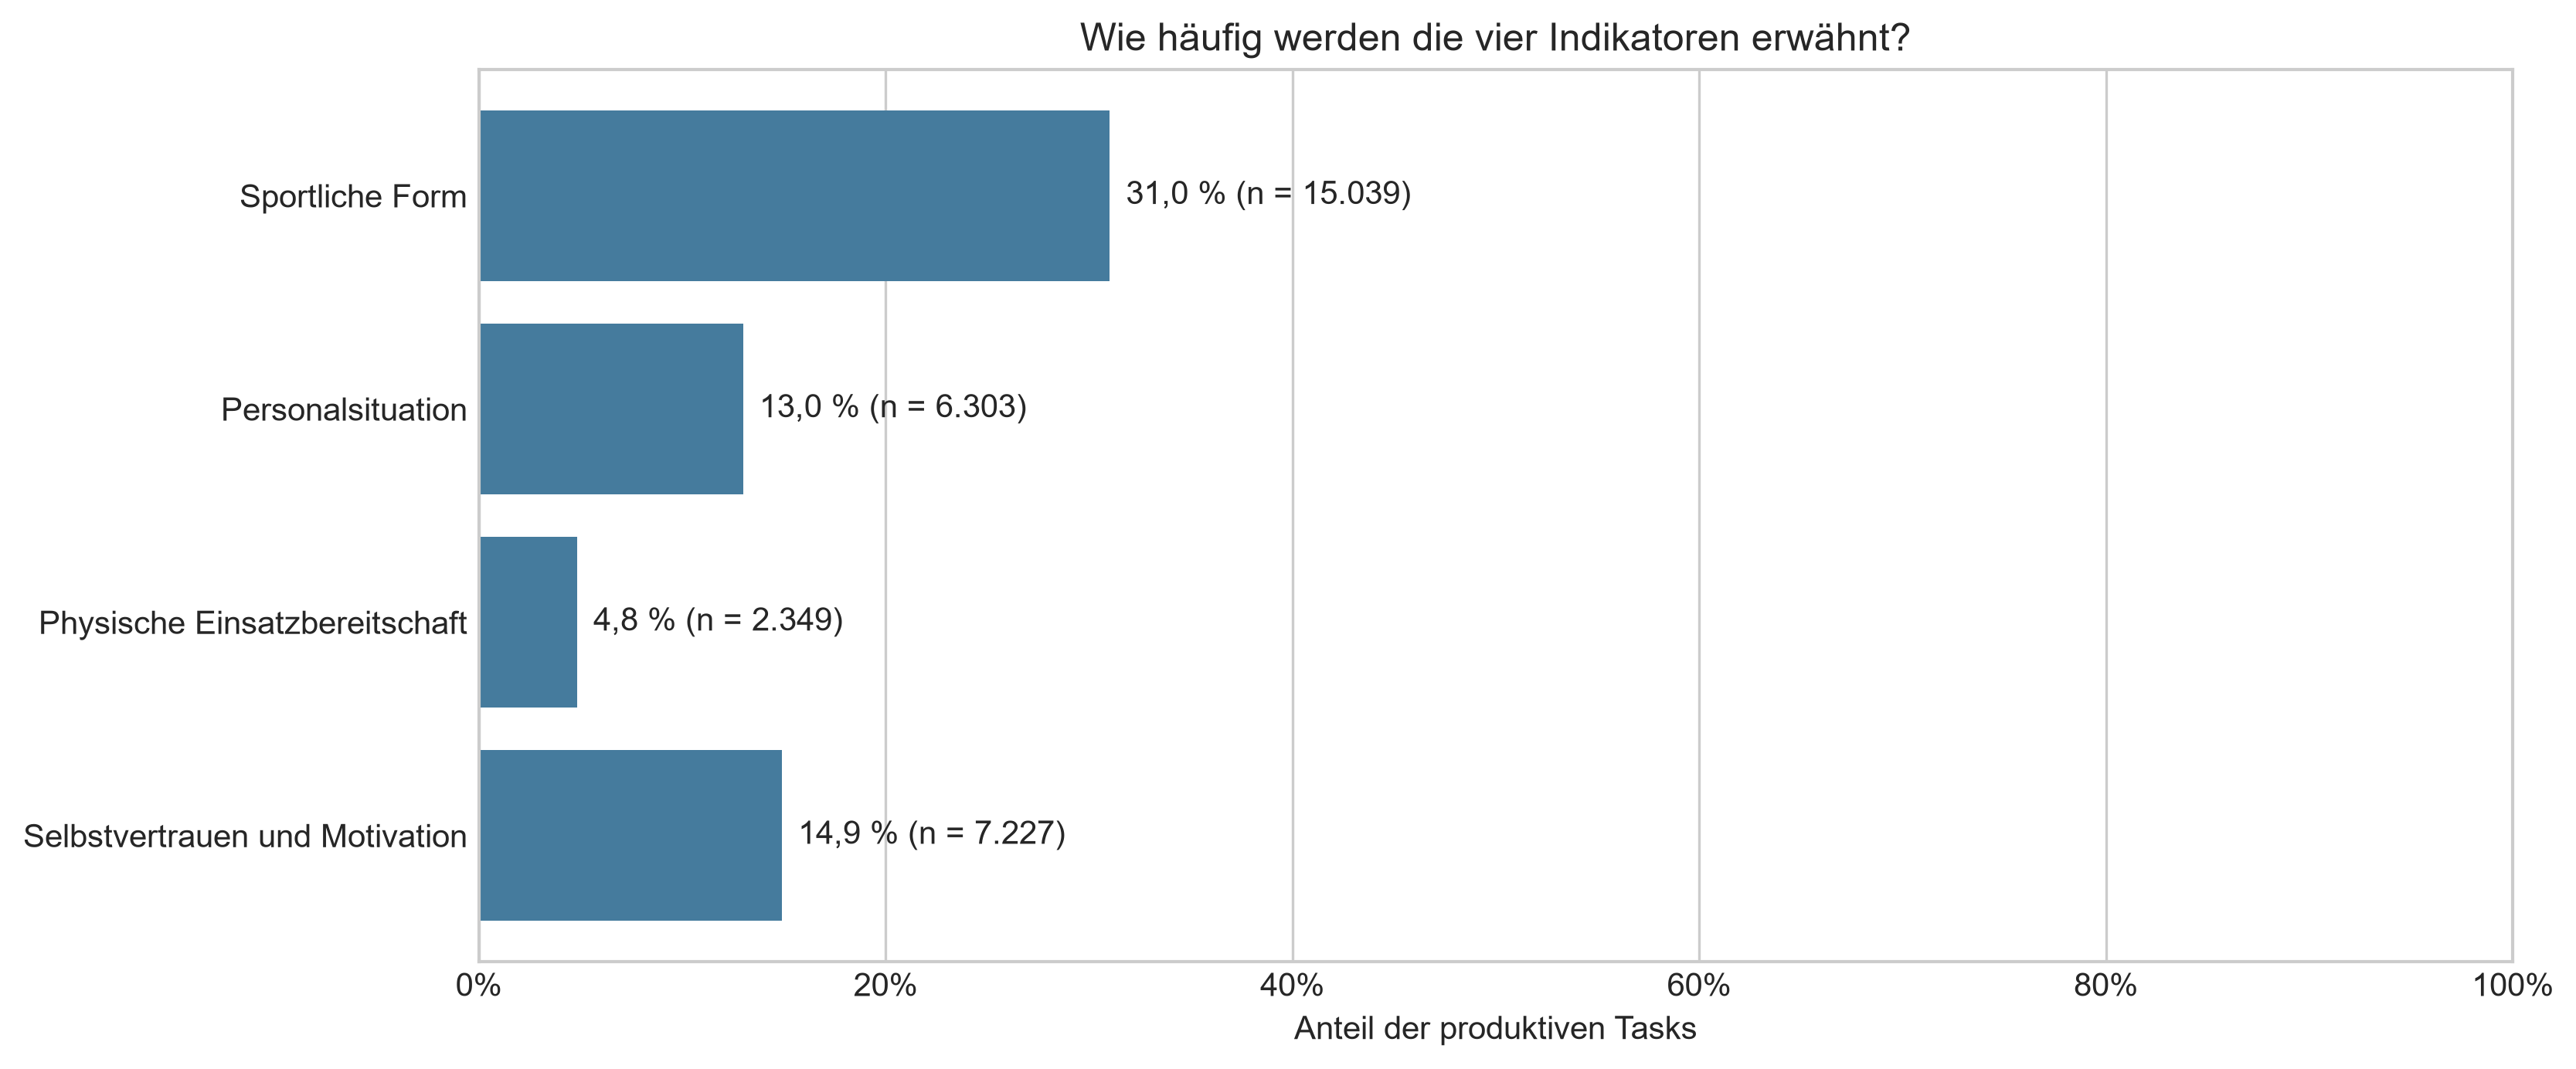

In [45]:
mention_summary = (
    annotation_data.groupby("indicator", sort=False)
    .agg(
        task_count=("task_id", "size"),
        mention_count=("mentioned", "sum"),
        mention_share=("mentioned", "mean"),
    )
    .reindex(list(INDICATOR_LABELS.values()))
)

fig, ax = plt.subplots(figsize=(11, 4.5), layout="constrained")
bars = ax.barh(
    mention_summary.index,
    mention_summary["mention_share"] * 100,
    color="#457b9d",
)
labels = [
    f"{share * 100:.1f}".replace(".", ",") + " % (n = "
    + f"{count:,}".replace(",", ".") + ")"
    for share, count in zip(
        mention_summary["mention_share"],
        mention_summary["mention_count"],
        strict=True,
    )
]
ax.bar_label(bars, labels=labels, padding=5)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.set_xlabel("Anteil der produktiven Tasks")
ax.set_title("Wie häufig werden die vier Indikatoren erwähnt?")
ax.grid(axis="y", visible=False)
plt.show()

### Ratingverteilungen innerhalb der erwähnten Fälle

Die fünf Balken je Indikator zeigen die prozentuale Verteilung der Ratings unter den erwähnten Fällen und summieren sich bei vorhandenen Erwähnungen auf 100 %. `not_mentioned` ist ausgeschlossen. Alle vier Diagramme verwenden dieselbe Y-Achsen-Skalierung. Die Titel enthalten den Mittelwert auf der kodierten Skala von −2 bis +2.

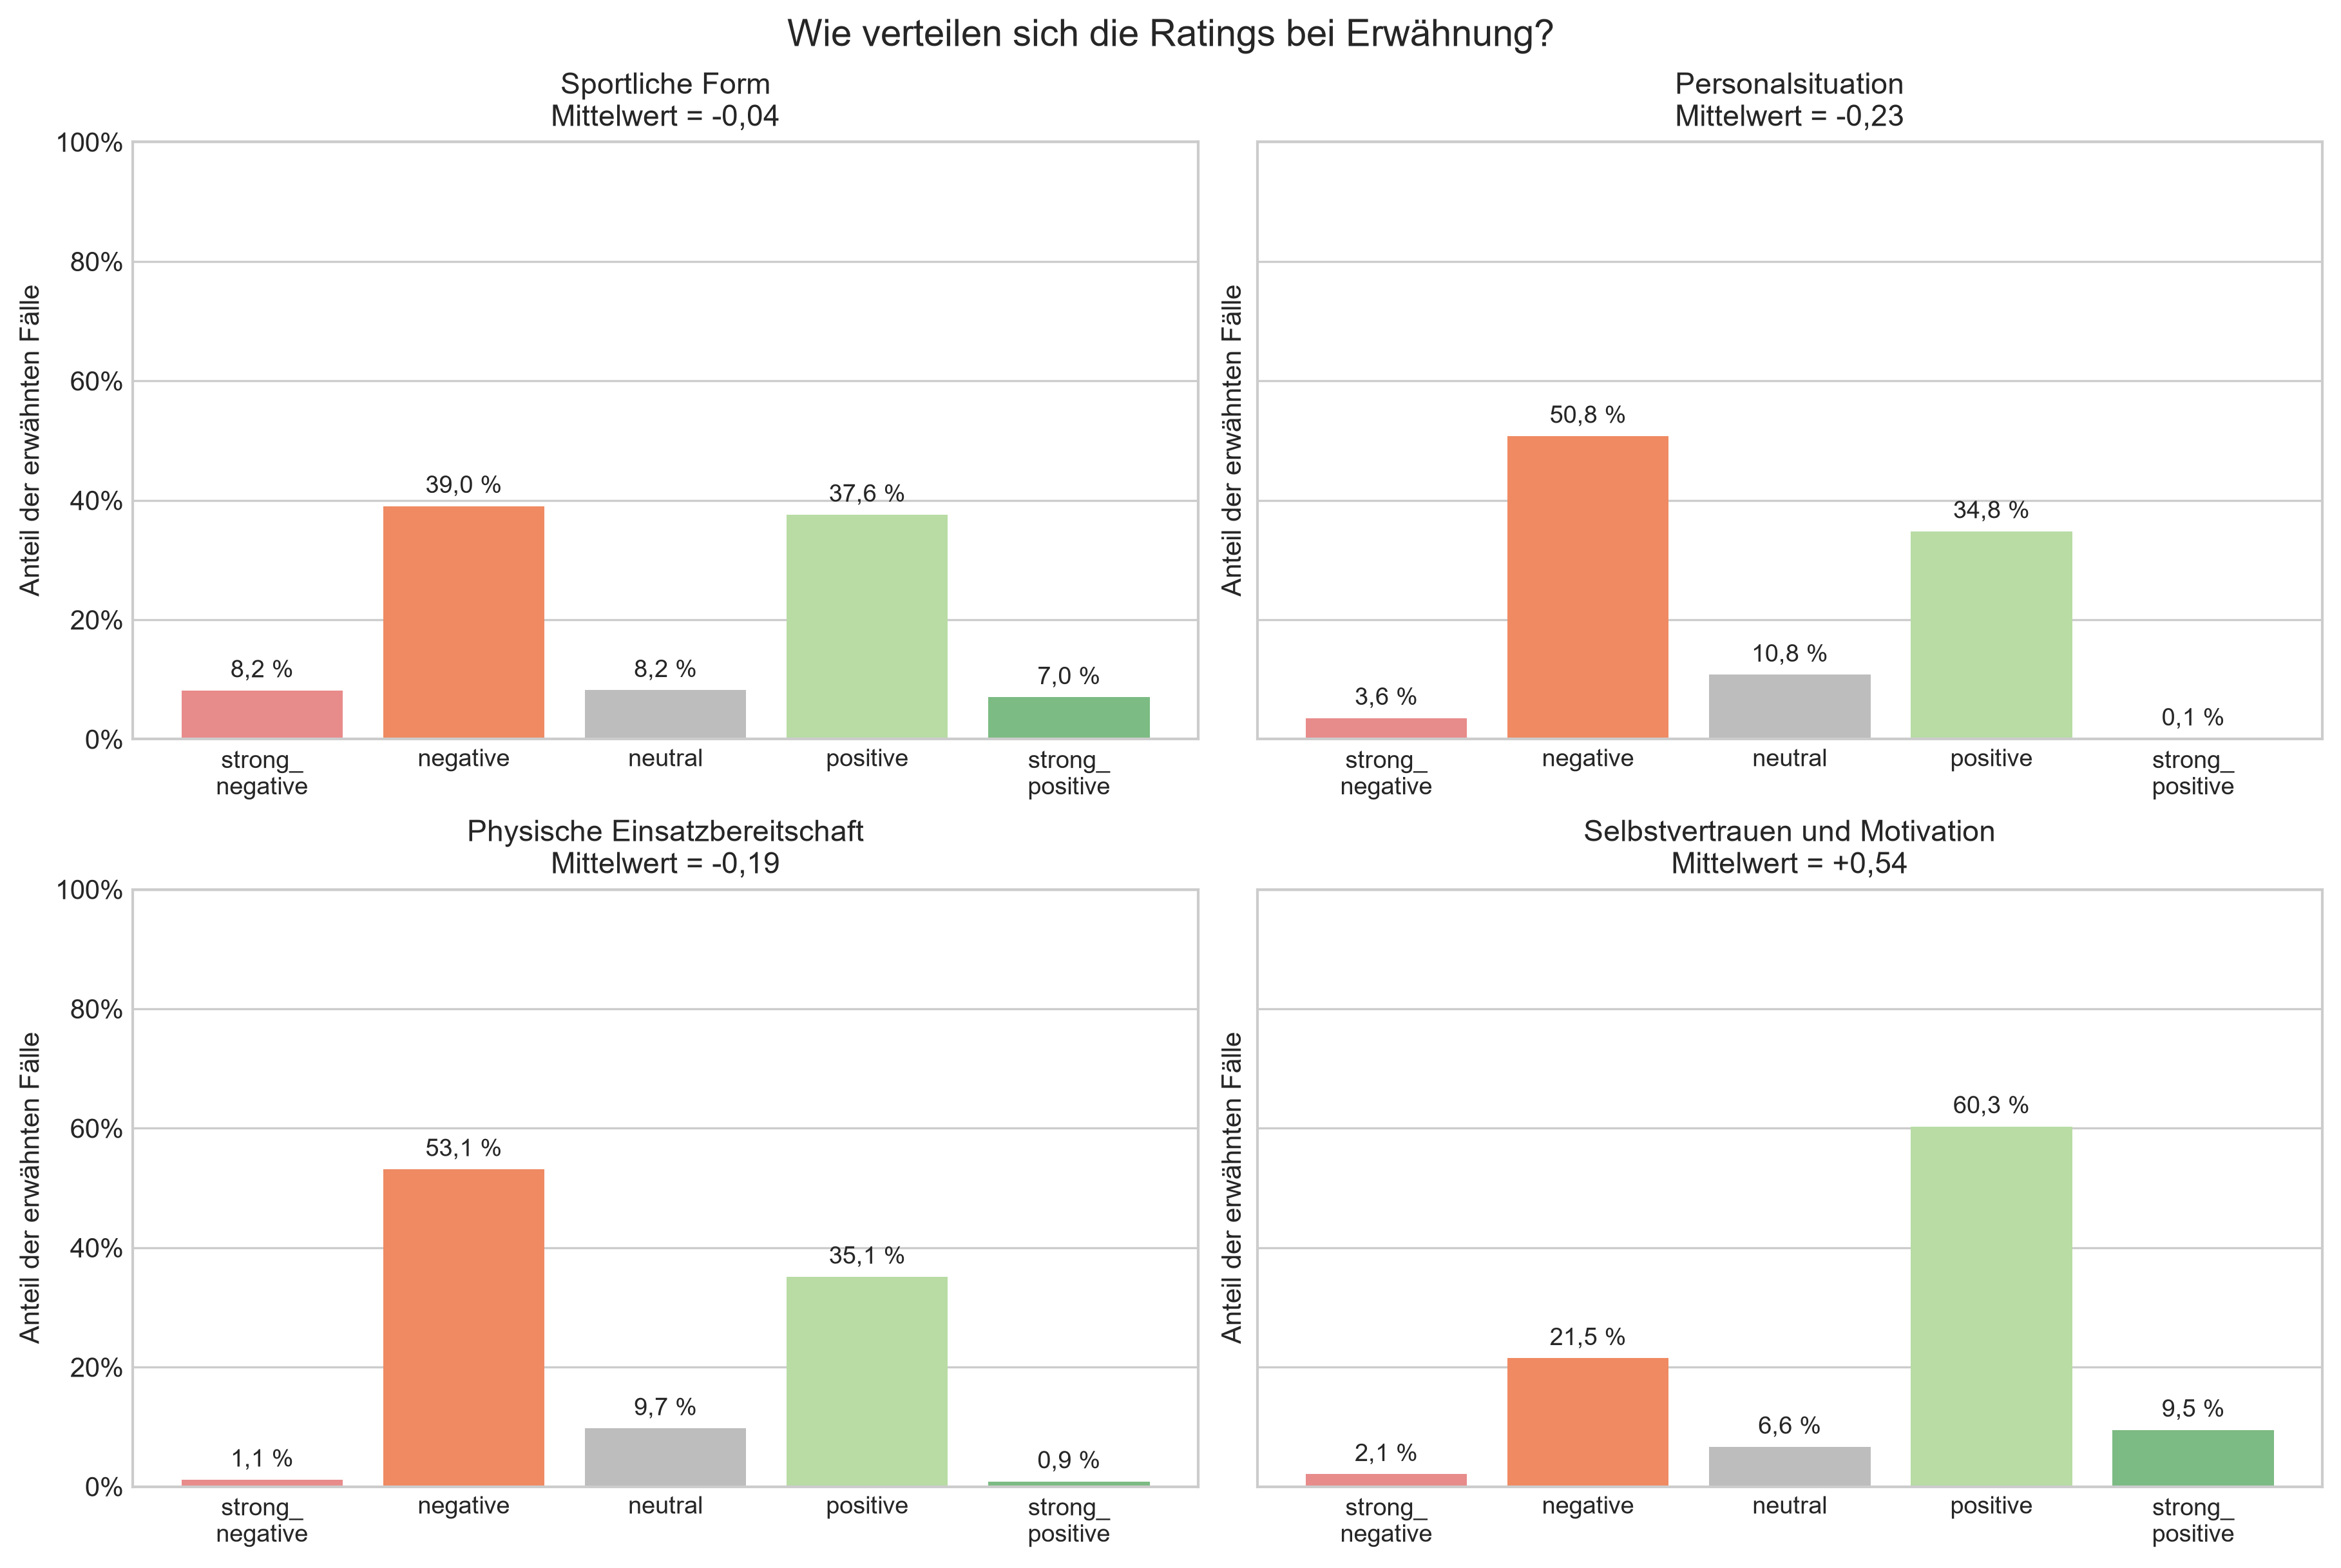

In [46]:
rating_values = list(RATING_VALUES.values())
rating_tick_labels = [
    "strong_\nnegative", "negative", "neutral", "positive", "strong_\npositive"
]
rating_colors = ["#e88b8b", "#ef8a62", "#bdbdbd", "#b8dca4", "#7cbb83"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True, layout="constrained")
for ax, indicator_label in zip(axes.flat, INDICATOR_LABELS.values(), strict=True):
    ratings = annotation_data.loc[
        annotation_data["indicator"].eq(indicator_label),
        "rating",
    ].dropna()
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.set_xticks(rating_values, rating_tick_labels, fontsize=9)
    ax.set_ylabel("Anteil der erwähnten Fälle")
    ax.grid(axis="x", visible=False)

    if ratings.empty:
        ax.set_title(indicator_label)
        ax.text(0.5, 0.5, "Keine erwähnten Fälle", ha="center", transform=ax.transAxes)
        continue

    rating_counts = ratings.value_counts().reindex(rating_values, fill_value=0)
    rating_percentages = rating_counts / len(ratings) * 100
    bars = ax.bar(rating_values, rating_percentages, color=rating_colors)
    ax.bar_label(
        bars,
        labels=[f"{value:.1f} %".replace(".", ",") for value in rating_percentages],
        padding=3,
        fontsize=9,
    )
    mean_rating = f"{ratings.mean():+.2f}".replace(".", ",")
    ax.set_title(
        f"{indicator_label}\nMittelwert = {mean_rating}",
        fontsize=11,
    )

fig.suptitle("Wie verteilen sich die Ratings bei Erwähnung?", fontsize=14)
plt.show()

## 3. Bias auf Vereinsebene

Die Heatmap zeigt für jeden Verein das durchschnittliche LLM-Rating der vier Indikatoren über alle produktiven Tasks, nicht nur über die 200 menschlich annotierten Tasks. `not_mentioned` wird ausgeschlossen; `neutral` zählt als 0. Jede Zelle nennt den Mittelwert auf der Skala von −2 bis +2 und mit **n** die Anzahl der bewerteten Tasks.

Rot steht für negative, Weiß für neutrale und Grün für positive Mittelwerte. Ohne Erwähnung bleibt der Mittelwert undefiniert; die Zelle ist grau und als „keine Bewertung“ gekennzeichnet. Jeder Task zählt gleich. Identische Artikel in verschiedenen Request-/Zielteam-Kontexten können daher mehrfach eingehen.

Unterschiede können auch auf die ausgewählten Nachrichten und die tatsächliche sportliche Situation zurückgehen. Sie sind zunächst Anhaltspunkte für weitere Untersuchungen.

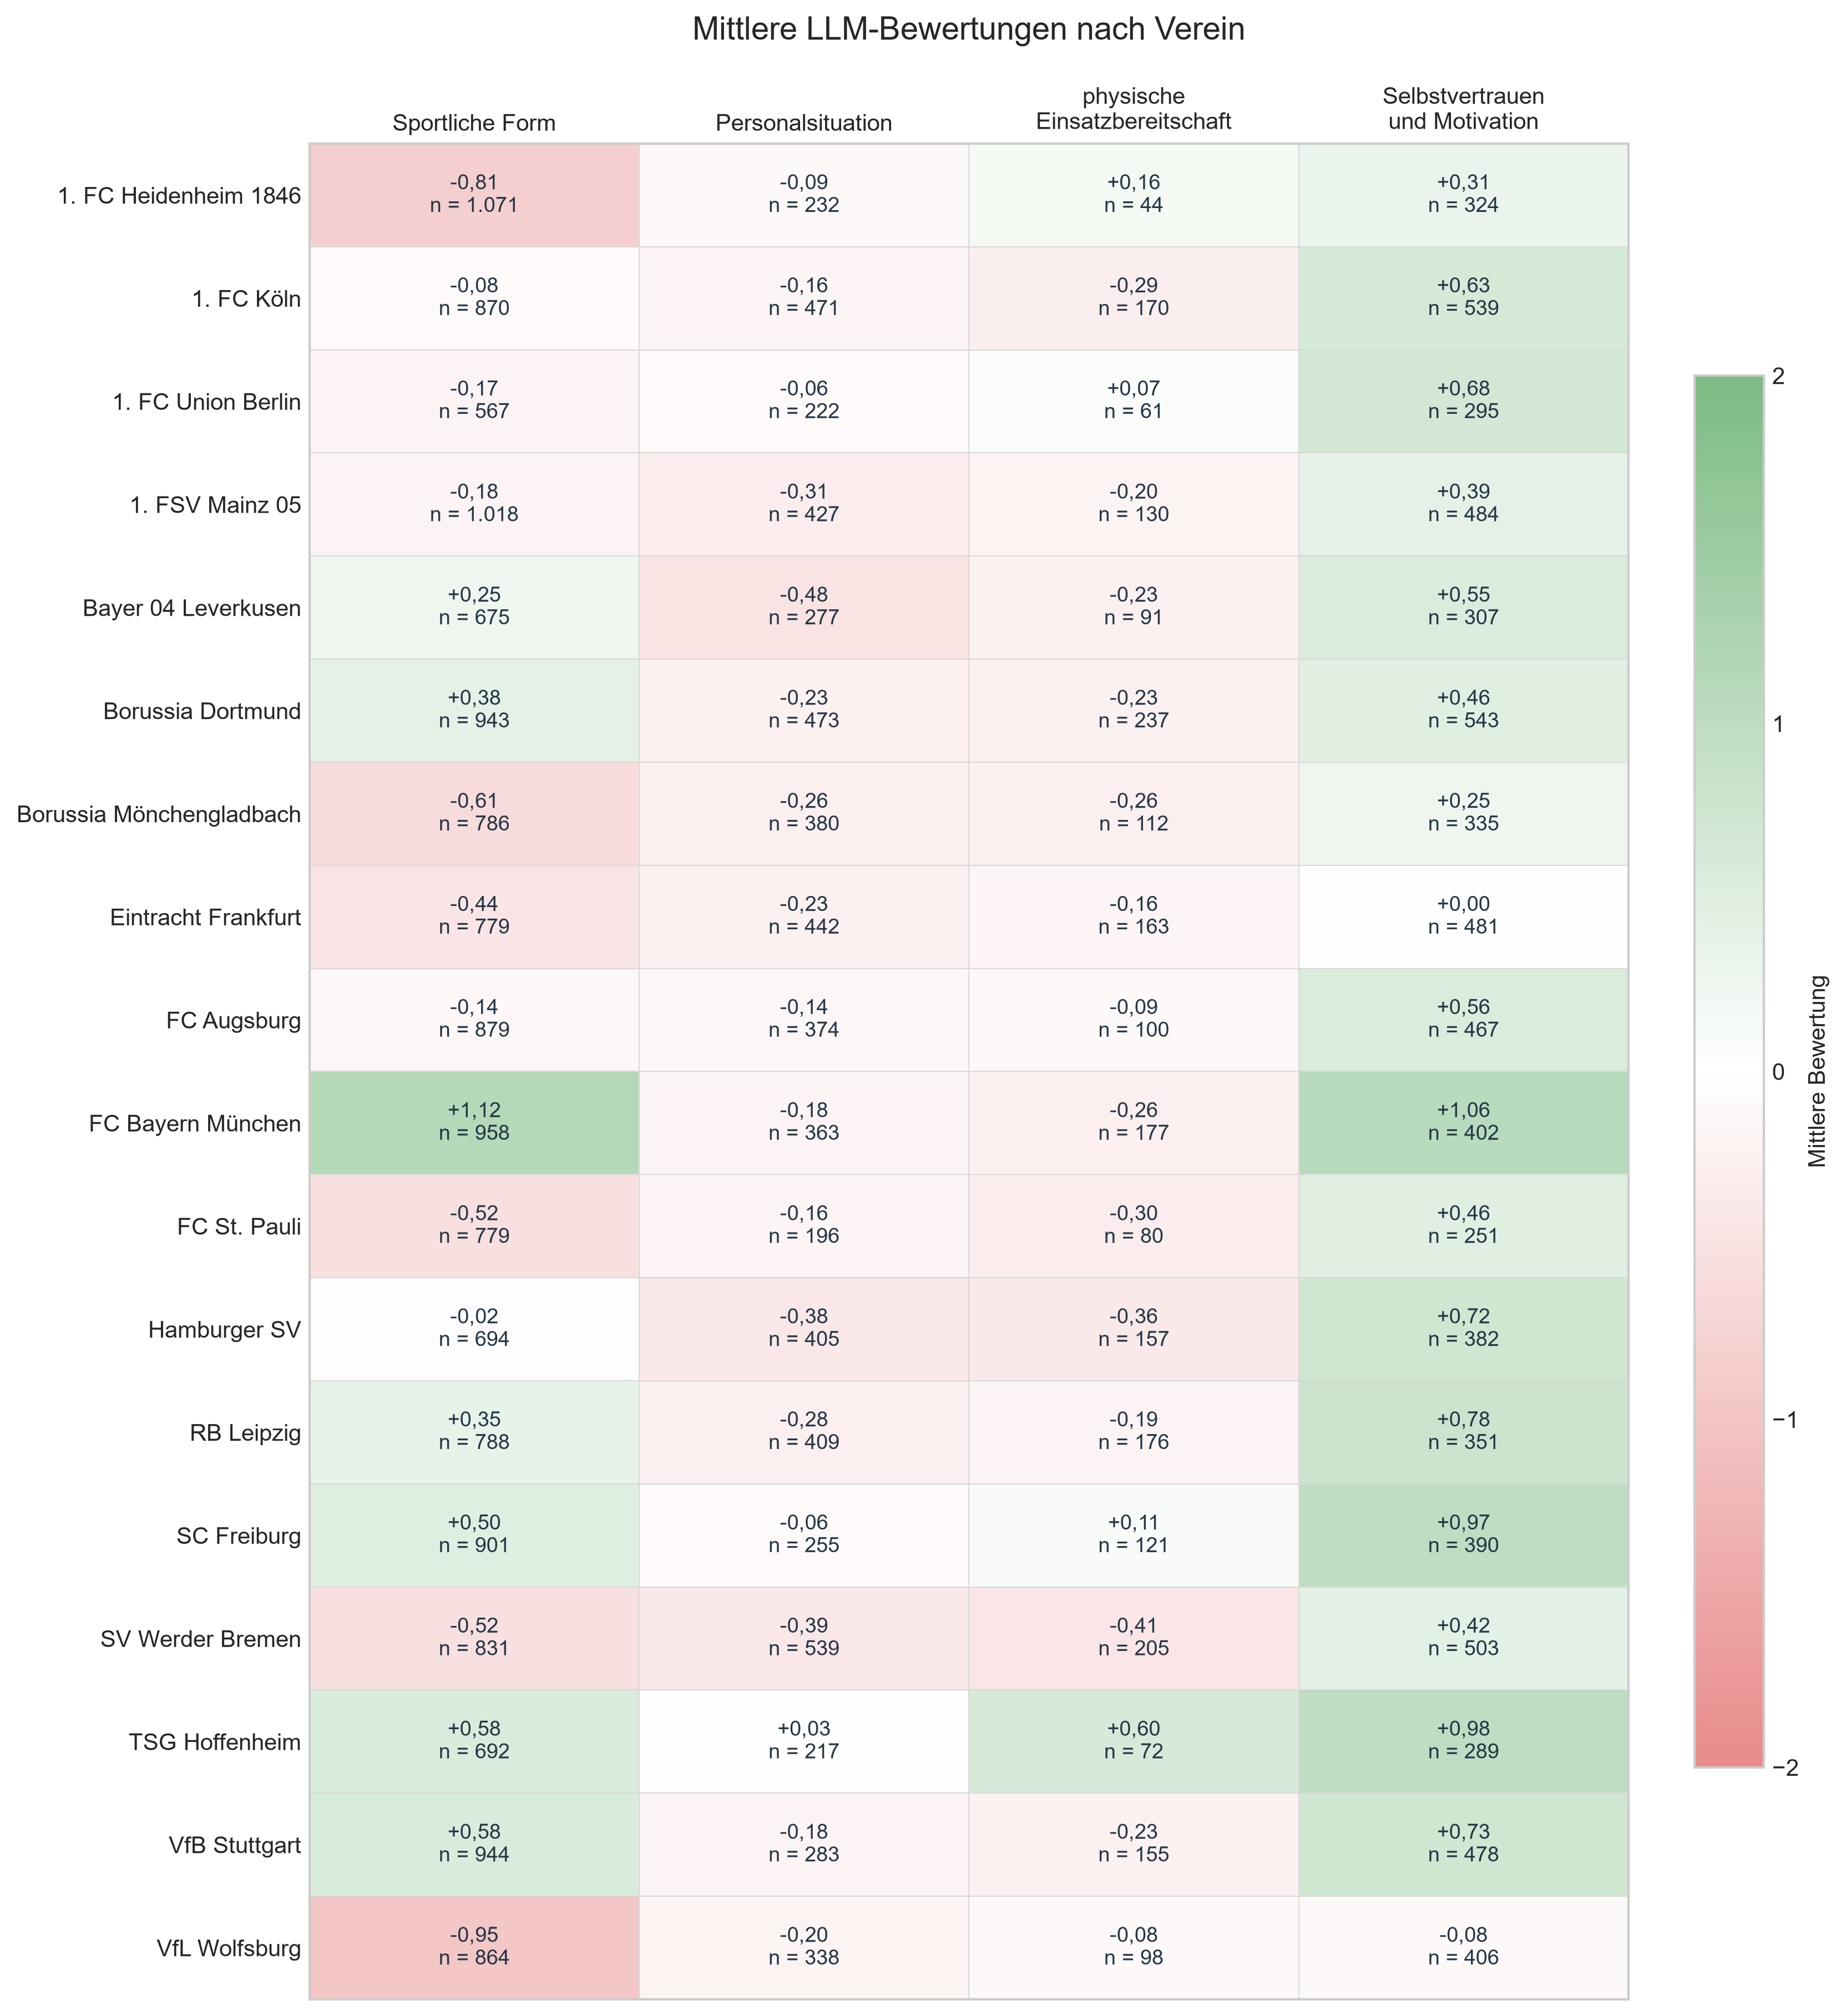

In [47]:
team_rating_summary = (
    annotation_data.groupby(["target_team", "indicator"])
    .agg(
        mean_rating=("rating", "mean"),
        rated_tasks=("rating", "count"),
    )
)
team_mean_ratings = (
    team_rating_summary["mean_rating"]
    .unstack("indicator")
    .reindex(columns=list(INDICATOR_LABELS.values()))
    .sort_index()
)
team_rating_counts = (
    team_rating_summary["rated_tasks"]
    .unstack("indicator")
    .reindex(index=team_mean_ratings.index, columns=team_mean_ratings.columns)
    .fillna(0)
    .astype(int)
)

team_rating_cmap = LinearSegmentedColormap.from_list(
    "team_ratings", ["#e88b8b", "#ffffff", "#7cbb83"],
).with_extremes(bad="#e5e5e5")

fig, ax = plt.subplots(figsize=(11, 12), layout="constrained")
heatmap = ax.imshow(
    team_mean_ratings.to_numpy(dtype=float),
    cmap=team_rating_cmap,
    vmin=-2,
    vmax=2,
    aspect="auto",
    interpolation="nearest",
)
ax.set_xticks(
    range(4),
    ["Sportliche Form", "Personalsituation", "physische\nEinsatzbereitschaft",
     "Selbstvertrauen\nund Motivation"],
    fontsize=10,
)
ax.set_yticks(range(len(team_mean_ratings)), team_mean_ratings.index, fontsize=10)
ax.xaxis.tick_top()
ax.set_title("Mittlere LLM-Bewertungen nach Verein", pad=45, fontsize=14)
ax.grid(False)
ax.set_xticks([position - 0.5 for position in range(5)], minor=True)
ax.set_yticks(
    [position - 0.5 for position in range(len(team_mean_ratings) + 1)], minor=True,
)
ax.grid(which="minor", color="#d9d9d9", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

for row in range(len(team_mean_ratings)):
    for column in range(4):
        mean_rating = team_mean_ratings.iloc[row, column]
        count = team_rating_counts.iloc[row, column]
        label = (
            f"{mean_rating:+.2f}".replace(".", ",")
            + "\nn = " + f"{count:,}".replace(",", ".")
            if pd.notna(mean_rating) else "keine\nBewertung"
        )
        ax.text(
            column, row, label, ha="center", va="center",
            fontsize=9, color="#243746",
        )

fig.colorbar(
    heatmap, ax=ax, shrink=0.75, ticks=[-2, -1, 0, 1, 2],
    label="Mittlere Bewertung",
)
plt.show()

## 4. Vergleich mit menschlichen Annotationen

In diesem Abschnitt vergleichen wir 200 von einem Menschen annotierte Tasks (`human_run`) mit den exakt gleichen 200 Tasks aus dem produktiven LLM-Lauf (`main_run`). Die Zuordnung erfolgt über die `task_id`.

Der erste Plot zeigt die Erwähnungsanteile von `main_run` und `human_run` pro Indikator. Alle Anteile beziehen sich auf dieselben 200 Task-Paare. Jedes Rating außer `not_mentioned` zählt als Erwähnung; leere Bewertungen werden nicht als fehlende Erwähnung interpretiert.

Die menschliche Annotation dient als Referenz. Unterschiede zeigen Abweichungen zwischen Mensch und LLM, aber für sich allein noch keinen nachgewiesenen Bias.

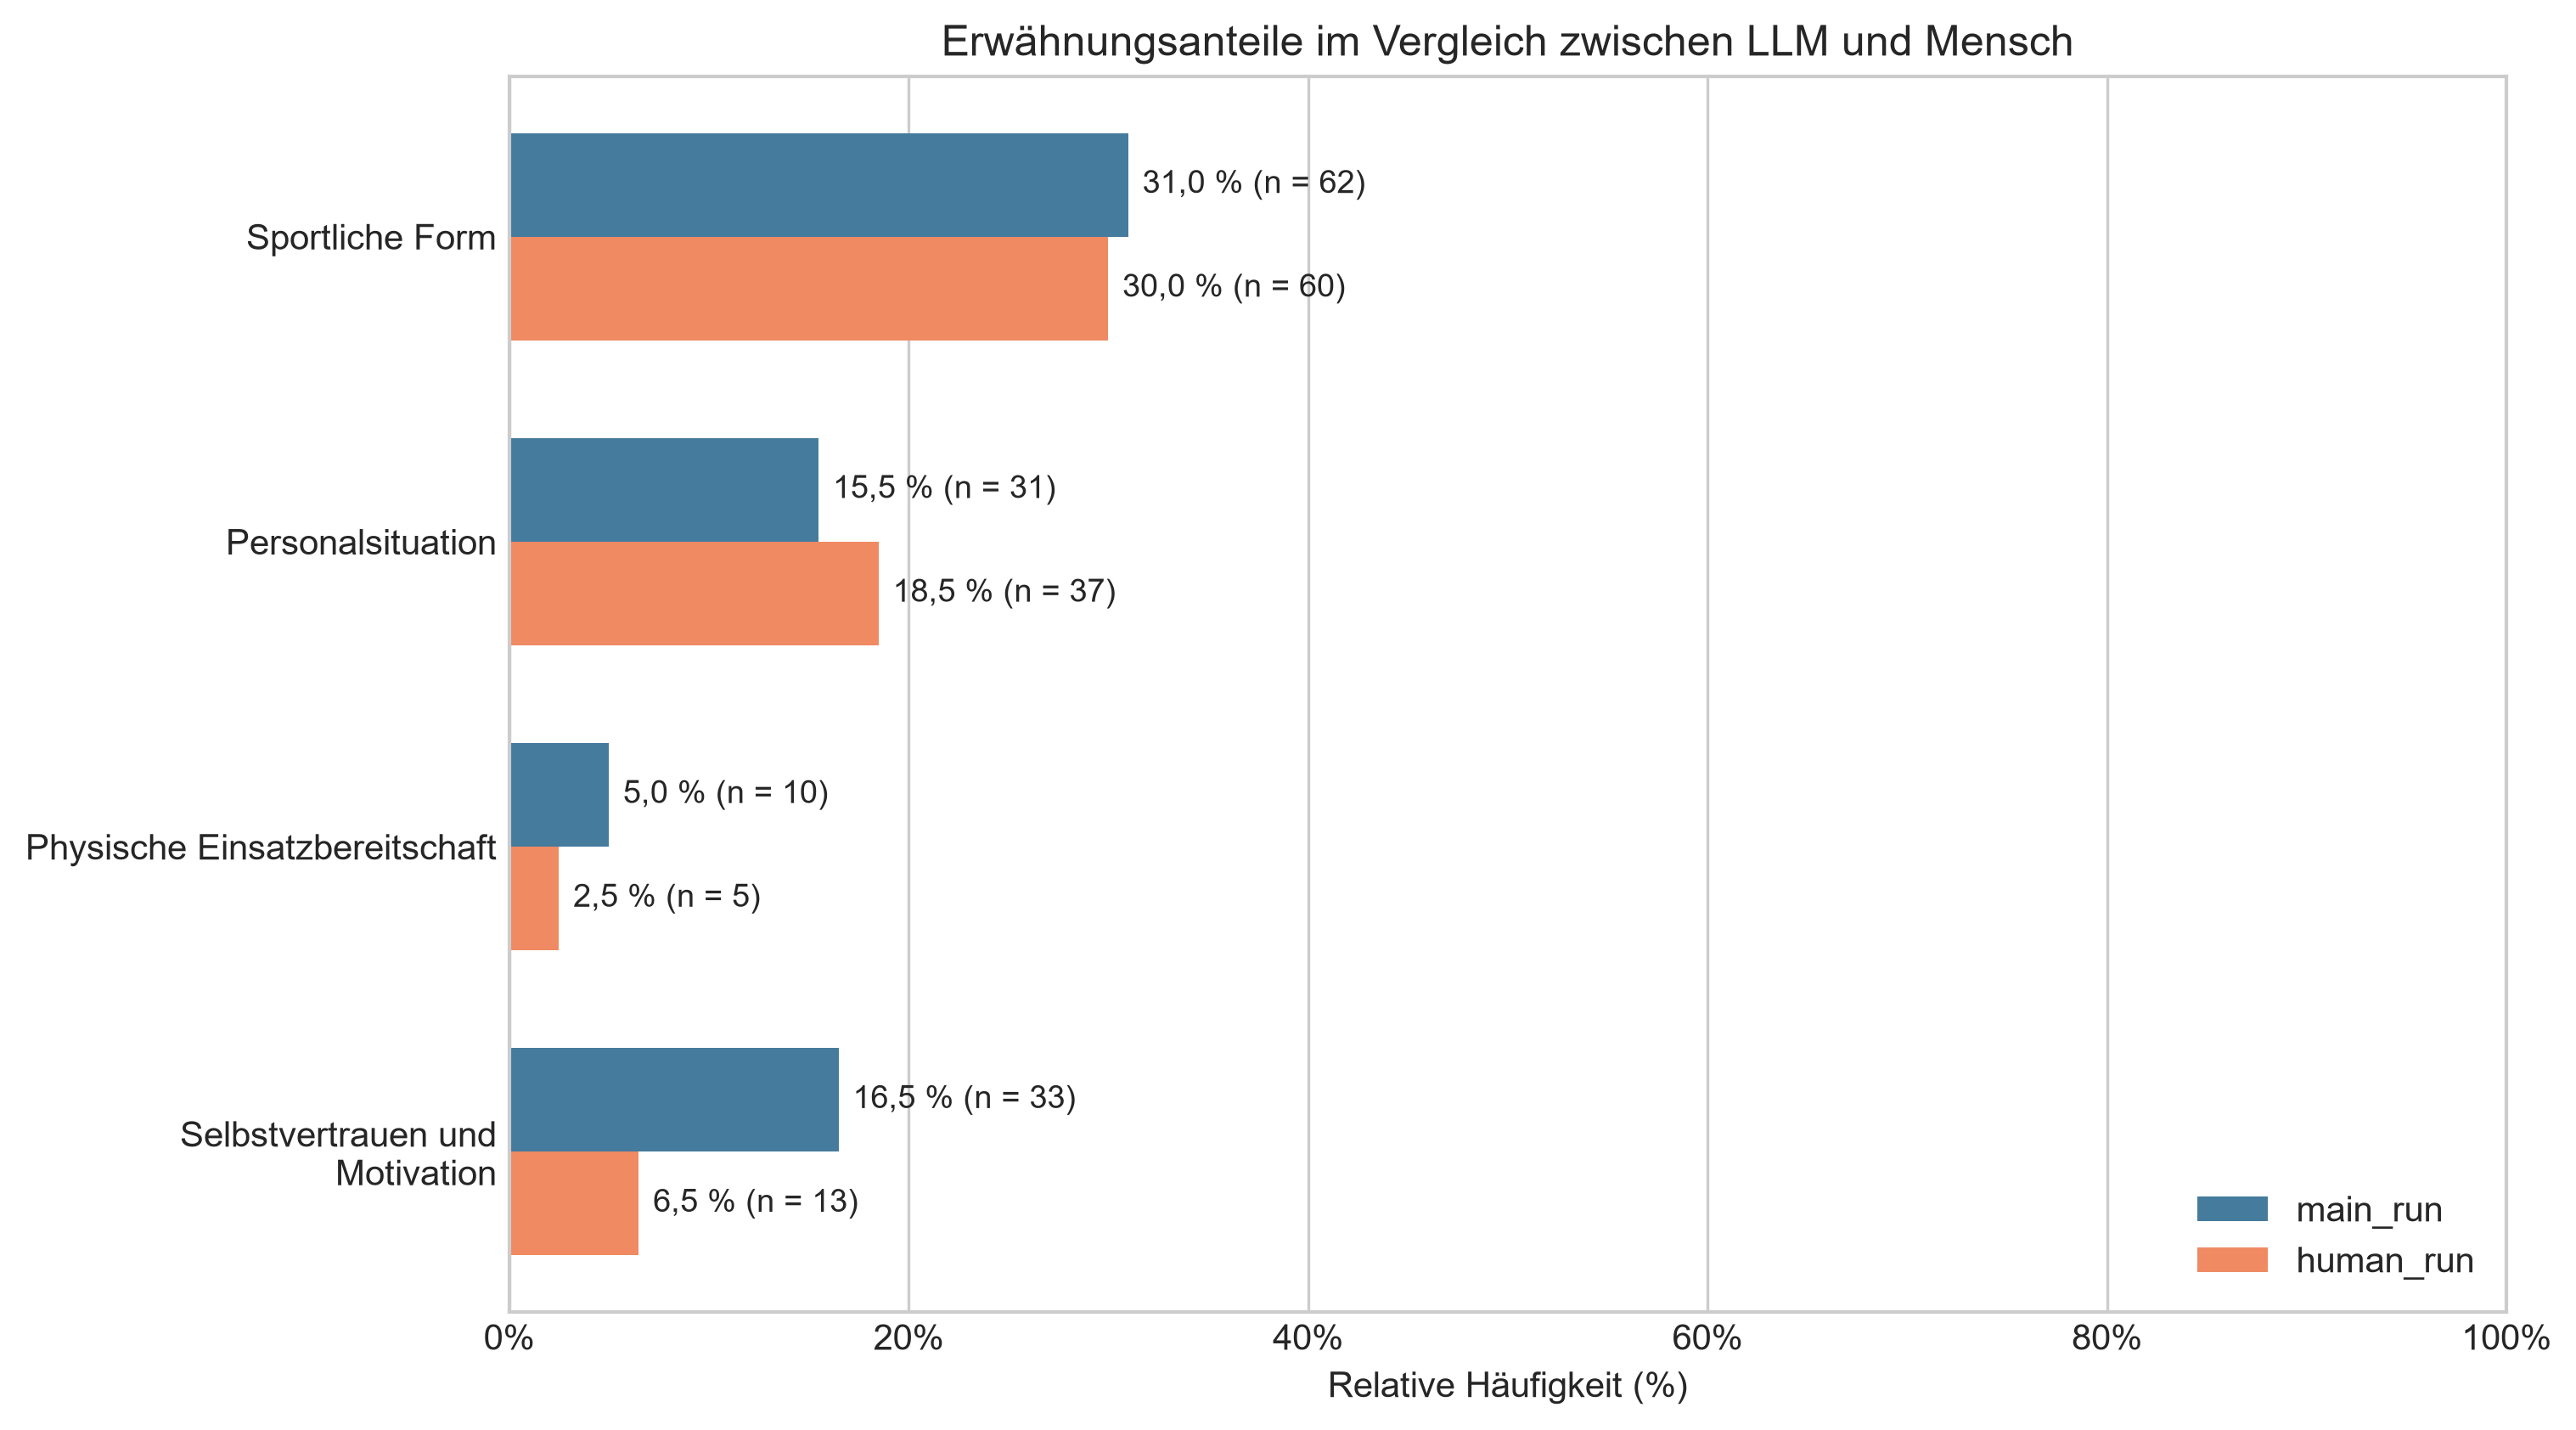

In [48]:
human_columns = list(INDICATOR_LABELS.values())
human_run = pd.read_excel(
    HUMAN_RUN_PATH,
    sheet_name="Tasks",
    usecols=["Taskid", *human_columns],
    dtype="string",
)
human_run = human_run.apply(lambda column: column.str.strip())
continuation_rows = human_run["Taskid"].isna()
if human_run.loc[continuation_rows, human_columns].notna().any().any():
    raise ValueError("Bewertungen ohne Taskid gefunden: Bitte die Fortsetzungszeilen prüfen.")
human_run = human_run.loc[~continuation_rows].set_index("Taskid").rename_axis("task_id")

if len(human_run) != 200 or not human_run.index.is_unique:
    raise ValueError("human_run muss genau 200 eindeutige Taskids enthalten.")
valid_ratings = [*RATING_VALUES, "not_mentioned"]
if not human_run.isin(valid_ratings).all().all():
    raise ValueError("human_run enthält fehlende oder ungültige Ratings. Bitte Excel vervollständigen.")
if not human_run.index.isin(annotations_by_task_id).all():
    raise ValueError("Nicht alle human_run-Tasks sind im main_run vorhanden.")

# Gleiche Taskids und gleiche Reihenfolge in beiden Läufen.
main_run = pd.DataFrame(
    [
        {
            label: annotations_by_task_id[task_id][indicator]["rating"]
            for indicator, label in INDICATOR_LABELS.items()
        }
        for task_id in human_run.index
    ],
    index=human_run.index,
)
human_mention_counts = pd.DataFrame({
    "main_run": main_run.ne("not_mentioned").sum(),
    "human_run": human_run.ne("not_mentioned").sum(),
}).reindex(human_columns)
human_mention_shares = human_mention_counts / len(human_run) * 100

fig, ax = plt.subplots(figsize=(10, 5.5), layout="constrained")
positions = list(range(len(human_columns)))
bar_height = 0.34
for index, (run, color) in enumerate(
    zip(["main_run", "human_run"], ["#457b9d", "#ef8a62"], strict=True)
):
    bars = ax.barh(
        [position + (index - 0.5) * bar_height for position in positions],
        human_mention_shares[run],
        height=bar_height,
        color=color,
        label=run,
    )
    ax.bar_label(
        bars,
        labels=[
            f"{share:.1f} % (n = {count})".replace(".", ",")
            for share, count in zip(
                human_mention_shares[run],
                human_mention_counts[run],
                strict=True,
            )
        ],
        padding=4,
        fontsize=9,
    )

ax.set_yticks(
    positions,
    [label.replace(" und ", " und\n") for label in human_columns],
)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.set_xlabel("Relative Häufigkeit (%)")
ax.set_title("Erwähnungsanteile im Vergleich zwischen LLM und Mensch")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", frameon=False)
plt.show()

### Verteilung der Bewertungsdifferenzen zwischen LLM und Mensch

Für jeden Indikator betrachten wir nur die Tasks, bei denen sowohl `main_run` als auch `human_run` eine Erwähnung erkannt haben. Die Ratings werden auf der Skala von −2 (`strong_negative`) bis +2 (`strong_positive`) kodiert. Anschließend berechnen wir **main_run − human_run**: Negative Differenzen bedeuten eine negativere LLM-Bewertung, null bedeutet dasselbe Rating und positive Differenzen eine positivere LLM-Bewertung.

Die vier Diagramme zeigen die prozentuale Verteilung der Differenzen von −4 bis +4 mit derselben Achsenskalierung. Die Anteile beziehen sich jeweils auf die gemeinsam erwähnten Fälle des Indikators, nicht auf alle 200 Tasks. Die Titel nennen diese Fallzahl und die mittlere Differenz. Bei wenigen Fällen sind die Ergebnisse besonders vorsichtig zu interpretieren.

Die Mittelwerte setzen gleiche Abstände zwischen den Ratingstufen voraus. Gegenläufige Abweichungen können sich im Mittel aufheben; deshalb betrachten wir auch die vollständige Verteilung. Abweichungen bei der Erwähnungserkennung sind hier ausgeschlossen.

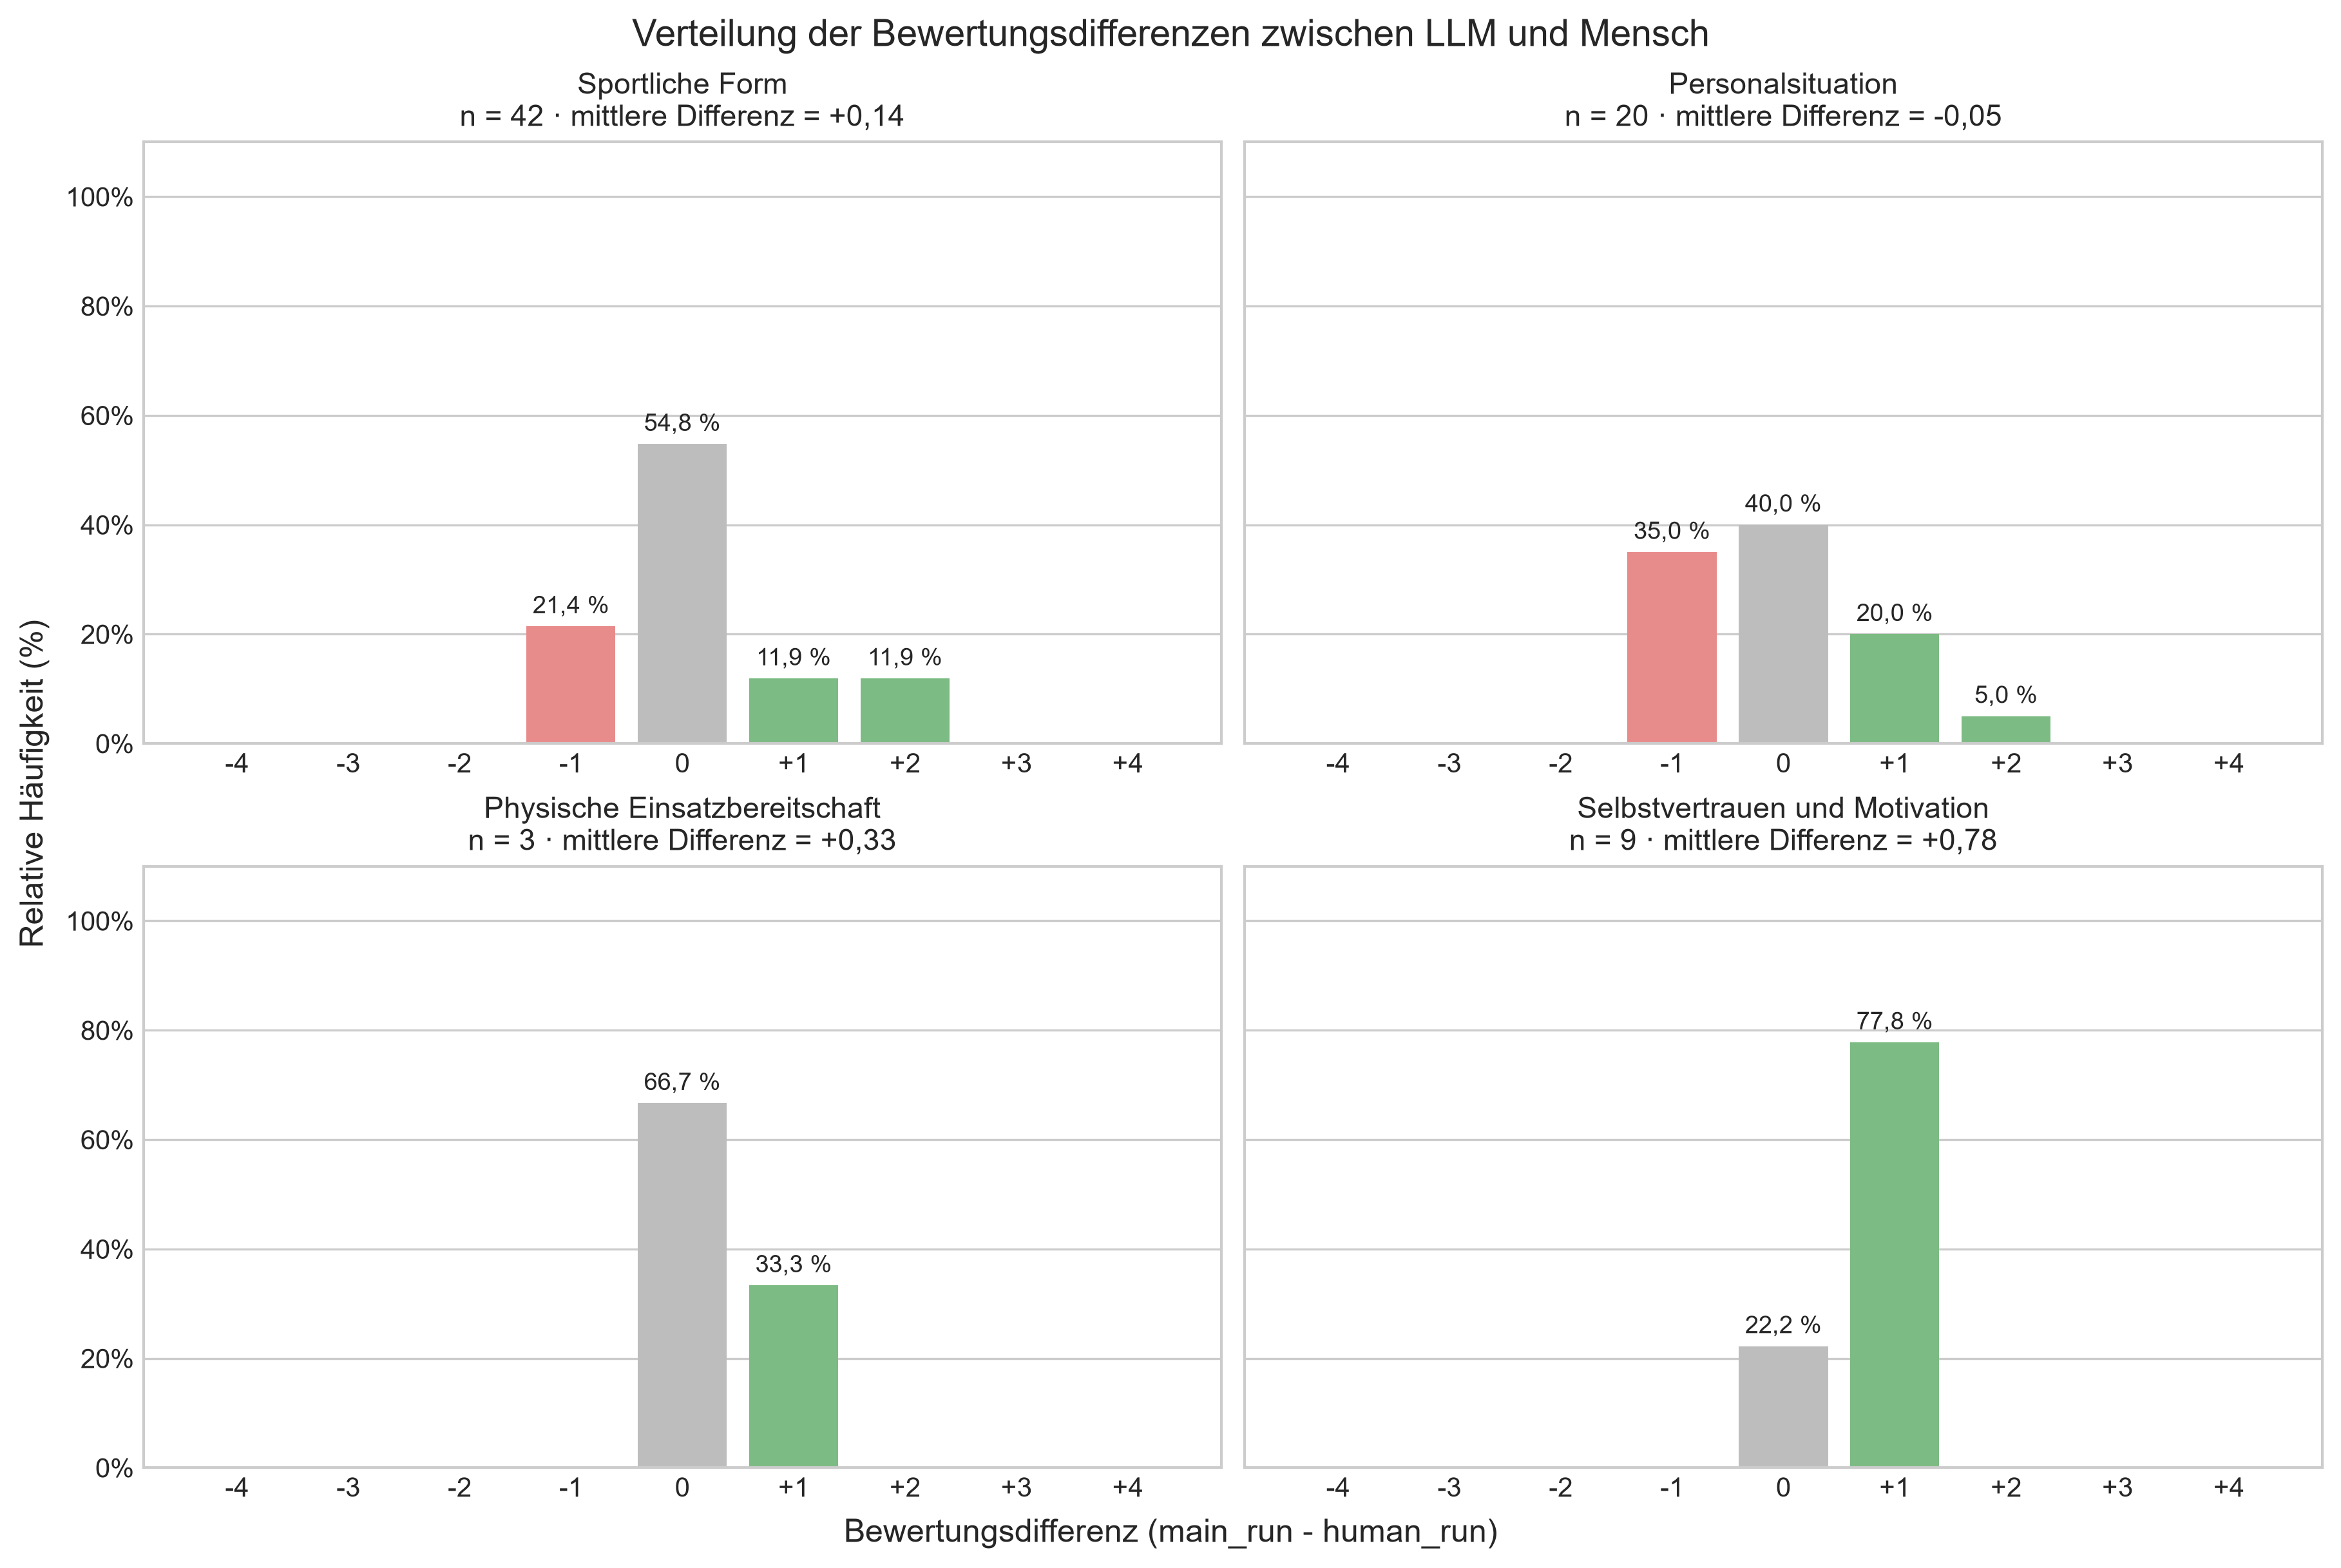

In [49]:
difference_values = list(range(-4, 5))
difference_colors = [
    "#e88b8b" if value < 0 else "#7cbb83" if value > 0 else "#bdbdbd"
    for value in difference_values
]
rating_differences = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True, layout="constrained")
for ax, indicator_label in zip(axes.flat, human_columns, strict=True):
    jointly_mentioned = (
        main_run[indicator_label].ne("not_mentioned")
        & human_run[indicator_label].ne("not_mentioned")
    )
    differences = (
        main_run.loc[jointly_mentioned, indicator_label].map(RATING_VALUES)
        - human_run.loc[jointly_mentioned, indicator_label].map(RATING_VALUES)
    ).astype(int)
    rating_differences[indicator_label] = differences

    ax.set_xticks(
        difference_values,
        [f"{value:+d}" if value else "0" for value in difference_values],
    )
    ax.set_ylim(0, 110)
    ax.set_yticks(range(0, 101, 20))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.grid(axis="x", visible=False)

    if differences.empty:
        ax.set_title(f"{indicator_label}\nn = 0 · mittlere Differenz nicht definiert")
        ax.text(
            0.5, 0.5, "Keine gemeinsam erwähnten Fälle",
            ha="center", transform=ax.transAxes,
        )
        continue

    difference_counts = differences.value_counts().reindex(difference_values, fill_value=0)
    difference_percentages = difference_counts / len(differences) * 100
    bars = ax.bar(difference_values, difference_percentages, color=difference_colors)
    ax.bar_label(
        bars,
        labels=[
            f"{value:.1f} %".replace(".", ",") if value > 0 else ""
            for value in difference_percentages
        ],
        padding=3,
        fontsize=9,
    )
    mean_difference = f"{differences.mean():+.2f}".replace(".", ",")
    ax.set_title(
        f"{indicator_label}\nn = {len(differences)} · mittlere Differenz = {mean_difference}",
        fontsize=11,
    )

fig.suptitle("Verteilung der Bewertungsdifferenzen zwischen LLM und Mensch", fontsize=14)
fig.supxlabel("Bewertungsdifferenz (main_run - human_run)")
fig.supylabel("Relative Häufigkeit (%)")
plt.show()

### Erläuterung der Abbildung

**Abbildungsanmerkung:** Berücksichtigt werden je Indikator ausschließlich Annotationsaufgaben, bei denen sowohl das LLM als auch der menschliche Annotator eine Erwähnung festgestellt haben. Die Prozentangaben beziehen sich auf die jeweilige Anzahl dieser Aufgaben (**n**). Positive Differenzen kennzeichnen eine positivere, negative Differenzen eine negativere Bewertung durch das LLM; null entspricht einer identischen Bewertung.

Die X-Achse zeigt **nicht das Rating selbst**, sondern die Differenz **LLM − Mensch** (`main_run − human_run`):

- **0 (grau):** Beide vergeben dasselbe Rating.
- **−1 (rot):** Das LLM bewertet eine Stufe negativer als der Mensch.
- **+1 (grün):** Das LLM bewertet eine Stufe positiver als der Mensch.
- **−2 oder +2:** Die Bewertungen liegen zwei Stufen auseinander; entsprechend gelten die weiteren Werte.

Die Balkenhöhe zeigt den prozentualen Anteil dieser Unterschiede. **n** ist die Anzahl der Tasks, bei denen beide den jeweiligen Indikator als erwähnt bewertet haben.

**Beispiel Selbstvertrauen und Motivation:** Bei neun gemeinsam erwähnten Tasks vergeben beide zweimal dasselbe Rating (22,2 % bei 0). Siebenmal bewertet das LLM eine Stufe positiver (77,8 % bei +1). Die mittlere Differenz beträgt deshalb +0,78. Das bedeutet nicht zwangsläufig eine positive Bewertung: Auch `neutral` beim LLM statt `negative` beim Menschen ergibt +1.

Der Vergleich gilt nur für diese gemeinsam erwähnten Fälle, nicht für alle 200 Tasks. Neun Fälle sind eine kleine Grundlage und belegen allein keinen Bias.